## Installation

To run this notebook, make sure you have THE NEWEST VERSION of 21cmSense installed -- to avoid conflicts between numpy versions, create a new environment to install this one, and only import power spectra that you already computed. 

Go inside the 21cmSense repo from the terminal, using
  ```python
  cd 21cmSense
```
and run from the terminal
  ```python
  git status
```
If red lines appear telling you that you have outdated files, run
  ```python
  git pull origin main
  git status
```
The second line should now print that you are synchronized with the folder. 

Once you have done it, you also need to run
  ```python
  pip3 install . 
```
from inside the folder. 

Finally, run the following command to install SKA related files.
  ```python
  pip install ska-ost-array-config --extra-index-url https://artefact.skao.int/repository/pypi-internal/simple
```
If this last line give you problems, check how to do it for mac in https://gitlab.com/ska-telescope/ost/ska-ost-array-config 


See details for the paper in: https://21cmsense.readthedocs.io/en/latest/tutorials/SKA_forecast.html

In [2]:
# Import the packages required for this tutorial
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


Import the fiducial power spectrum.

In [1]:
from runsims_FNL import * 
Lbox_fid = 100
Nbox_fid = 25

Gauss = import_stuff(Lbox_fid, Nbox_fid, 
            fnl = 0., 
            force_mmax = 14., 
            kcut_fnl = 1e-3, 
            USE_MINI_HALOS = False, 
            nongauss_IC = False, 
            nongauss_fcollcond = False, 
            nongauss_fcolluncond = False, 
            use_lidz_approx = False, 
            use_ld_cond = True, 
            use_edg_uncond = True, 
            max_epsilon = 0., 
            extra_dim_fnl = 1., )

-----------------------------------------------------
SarahLibanore: developed f_nl in IC and fcoll, fixed on 06/17/2026
-----------------------------------------------------


Assign the variables.

In [3]:
z_global, T21, xH, z_pk, k, pk, box_0, box_1, box_2, box_3, box_4 = Gauss

## Compute SKA noise with 21cmSense

Below we compute SKA's sensitivity to the 21cm power spectrum with the 21cmSense package.

In [4]:
# import the following function from the experiment module
import py21cmsense as p21sense
from py21cmsense import GaussianBeam, Observatory, Observation, PowerSpectrum, hera

# 21cmSense makes use of the astropy package, for which we need to import the following modules
from astropy import units as un
from astropy.cosmology.units import littleh
from astropy.cosmology import Planck18

from py21cmfast import experiment
from tqdm import tqdm
import warnings

For SKA, un the next function insted of run_21cmSense.


Inputs are: 
- *z_values*: the z array associated with the power spectrum
- *k_values*: the k array associated with the power spectrum
- *power_spectrum*: the power spectrum from the simulations. We can use the same frequency array that we used for HERA. 
- *hlittle*: the value used in the cosmo params
- *which_obs*: There are two different SKA configurations, "AASTAR" and "AA4". AA4 has more stations (512) than AA* (307);AA4 has more stations clustered at the centre than AA*. Therefore, AA4 is more optimistic and futuristic. We should check both.
- *foregrounds*: "moderate" or "optimistic"
- *survey_type*: "deep", "multi", "drift". In "deep" we observe the sky for 6 hours a day and track the same patch of sky during the entire observation. In "multi" we observe the sky for 6 hours a day and track the same patch of sky for 3 hours before switching to a different patch (multiple fields but less deep). In "drift"  we observe the sky for 6 hours a day and do not track i.e. drift scan mode (HERA-like).

In [5]:
def run_21cmSense_SKA(z_values, k_values, power_spectrum, hlittle, which_obs, foregrounds, survey_type, substat = False):

    if not substat:
        try:
            observatory = Observatory.from_ska("LOW_FULL_" + which_obs)
        except:
            print('Check observatory')
            return -1
    else:
        try:
            observatory =Observatory.from_ska("LOW_SUBSTATION_18M_INNER_R350M_" + which_obs)
        except:
            print('Check observatory')
            return -1

    observation_params = {}
    observation_params["ndays"] = 180.0
    observation_params["h"] = hlittle
    observation_params["redshifts"] = z_values
    observation_params["time_per_day_hrs"] = 6.0
    observation_params["foreground_model"] = foregrounds

    if survey_type == 'deep':
        observation_params["lst_bin_size"] = observation_params["time_per_day_hrs"] * un.hour
    elif survey_type == 'multi':
        observation_params["lst_bin_size"]=3.0 * un.hour
    elif survey_type == 'drift':
        observation_params["lst_bin_size"]=Observatory.observation_duration
    else: 
        print("Check survey type")
        return -1 
    
    signal = {}
    noise = {}
    k_noise = {}
    sensitivities = {}

    # Run 21cmSense for each redshift.
    for z_ind,z in tqdm(enumerate(z_values),
                                desc="21cmSense",
                                unit="redshift",
                                disable=False,
                                total=len(z_values)):
        
        band = 1420.4 / (z + 1.0)
        
        observation = Observation(observatory=observatory,
            lst_bin_size=observation_params["time_per_day_hrs"] * un.hour,
            time_per_day=observation_params["time_per_day_hrs"] * un.hour,
            n_days=observation_params["ndays"],
            #cosmo=observation_params["cosmo"],
            coherent=True,
            # To point to dish off-zenith, use: phase_center_dec=-30.0*un.deg,
            # max baseline is 73km and there are ~260k bls so the gridding takes a very long time.
            # we add a baseline filer to only keep baselines up to 1km.
            baseline_filters=p21sense.BaselineRange(bl_max=1e3 * un.m),)
        
        theory_model = experiment.THEORY_MODEL(z_values,
                                            k_values,
                                            power_spectrum)
        sensitivity = PowerSpectrum(
            observation=observation, foreground_model=observation_params['foreground_model'], theory_model=theory_model).at_frequency(band*un.MHz)

        # Run 21cmSense!
        with np.errstate(divide='ignore'): # Don't show division by 0 warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore") # Don't show extrapolation warnings
                noise_z = sensitivity.calculate_sensitivity_1d().value
        k_sense = sensitivity.k1d.value * hlittle # 1/Mpc

        # Interpolate the 21cmFast data at the 21cmSense k-bins
        signal_z = interp1d(k_values,
                            power_spectrum[z_ind,:],
                            kind='cubic',bounds_error=False)(k_sense)

        signal[z] = signal_z
        noise[z] = noise_z
        k_noise[z] = k_sense
        sensitivities[z] = sensitivity

    noise_data = experiment.NOISE_DATA(power_spectrum = power_spectrum,
                    z_values = z_values,
                    signal = signal,
                    noise = noise,
                    k_noise = k_noise,
                    sensitivities = sensitivities)
    
    return noise_data

Use noise data in the same way in which you used the dictionary with the HERA noise before.

The next cell is just for verification.

In [6]:
# print('\nDoing AASTAR - deep')
# aas_deep = run_21cmSense_SKA(z_values=z_pk, k_values=k, power_spectrum=pk,hlittle=0.6736, which_obs='AASTAR', foregrounds='moderate', survey_type='deep')

# print('\nDoing AA4 - deep')
# aa4_deep = run_21cmSense_SKA(z_values=z_pk, k_values=k, power_spectrum=pk,hlittle=0.6736,which_obs='AA4', foregrounds='moderate', survey_type='deep')

# print('\nDoing AASTAR - multi')
# aas_multi = run_21cmSense_SKA(z_values=z_pk, k_values=k, power_spectrum=pk,hlittle=0.6736,which_obs='AASTAR', foregrounds='moderate', survey_type='multi')

# print('\nDoing AA4 - multi')
# aa4_multi = run_21cmSense_SKA(z_values=z_pk, k_values=k, power_spectrum=pk,hlittle=0.6736, which_obs='AA4', foregrounds='moderate', survey_type='multi')

# print('\nDoing AASTAR - drift')
# aas_drift = run_21cmSense_SKA(z_values=z_pk, k_values=k, power_spectrum=pk,hlittle=0.6736,which_obs='AASTAR', foregrounds='moderate', survey_type='drift')
# print('\nDoing AASTAR - drift substat')
# aas_drift_substat = run_21cmSense_SKA(z_values=z_pk, k_values=k, power_spectrum=pk,hlittle=0.6736,which_obs='AASTAR', foregrounds='moderate', survey_type='drift', substat=True)

print('\nDoing AA4 - drift substat')
aa4_drift_substat = run_21cmSense_SKA(z_values=z_pk,k_values=k,  power_spectrum=pk,hlittle=0.6736,which_obs='AA4', foregrounds='moderate', survey_type='drift', substat=True)

# print('\nDoing AASTAR - deep - optimistic')
# aas_deep_opt = run_21cmSense_SKA(z_values=z_pk,k_values=k,  power_spectrum=pk,hlittle=0.6736,which_obs='AASTAR', foregrounds='optimistic', survey_type='deep')

# print('\nDoing AA4 - deep - optimistic')
# aa4_deep_opt = run_21cmSense_SKA(z_values=z_pk, k_values=k, power_spectrum=pk,hlittle=0.6736,which_obs='AA4', foregrounds='optimistic', survey_type='deep')


Doing AA4 - drift substat


finding redundancies: 100%|██████████| 571/571 [00:16<00:00, 34.50ants/s] 


: 

Text(0.5, 1.0, '$z=6.17377$')

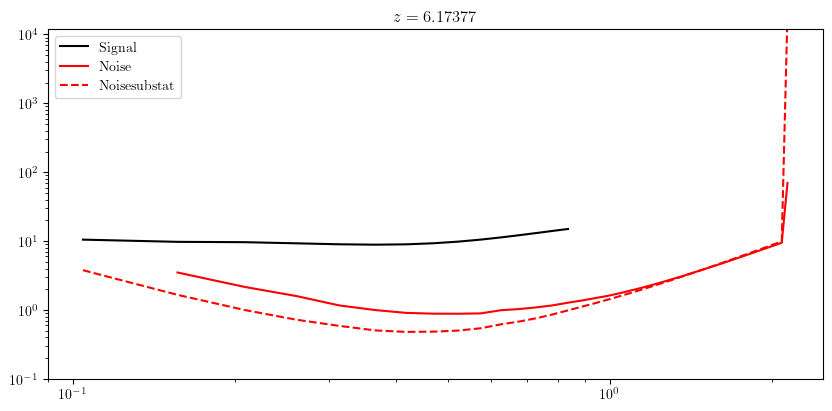

In [ ]:
z_id = aas_drift.z_values[0]

plt.figure(figsize=(10,10))
plt.subplot(211)
# plt.loglog(aas_drift.k_noise[z_id], aas_drift.signal[z_id],c='k',ls='-',label=r'$\rm Signal$')
# plt.loglog(aas_drift.k_noise[z_id], aas_drift.noise[z_id],c='r',ls='-',label=r'$\rm Noise$')
# plt.loglog(aas_drift_substat.k_noise[z_id], aas_drift_substat.noise[z_id],c='r',ls='--',label=r'$\rm Noise\, substat$')
plt.loglog(aa4_drift_substat.k_noise[z_id], aa4_drift_substat.noise[z_id],c='b',ls='--',label=r'$\rm AA4\,Noise\, substat$')
# plt.loglog(aas_deep.k_noise[z_id], aas_deep.noise[z_id],c='r',ls='-',label=r'$\rm Deep - AA*$')
# plt.loglog(aas_deep_opt.k_noise[z_id], aas_deep_opt.noise[z_id],c='g',ls='-',label=r'$\rm Deep+opt - AA*$')

plt.ylim(1e-1,1.2e4)
plt.legend()
plt.title(r'$z=%g$'%z_id)

# k_id = 10

# plt.subplot(212)
# signal_z = np.zeros(len(aas_deep.z_values))
# aas_deep_noise_z = np.zeros(len(aas_deep.z_values))
# aas_deep_opt_noise_z = np.zeros(len(aas_deep.z_values))
# for zz in aas_deep.z_values:
#     signal_z[list(aas_deep.z_values).index(zz)] = aas_deep.signal[zz][k_id]
#     aas_deep_noise_z[list(aas_deep.z_values).index(zz)] = aas_deep.noise[zz][k_id]
#     aas_deep_opt_noise_z[list(aas_deep.z_values).index(zz)] = aas_deep_opt.noise[zz][k_id]

# plt.semilogy(aas_deep.z_values, signal_z,c='k',ls='-',)
# plt.semilogy(aas_deep.z_values, aas_deep_noise_z,c='r',ls='-',)
# plt.semilogy(aas_deep_opt.z_values, aas_deep_opt_noise_z,c='g',ls='-',)

# plt.ylim(1e-1,1.1e3)
# plt.legend()
# plt.xlim(5,23)
# plt.title(r'$k=%g{\,\rm Mpc}^{-1}$'%aas_deep.k_noise[z_id][k_id])
